In [92]:
from sklearn.neighbors import KNeighborsRegressor,KNeighborsClassifier
import pandas as pd
from sklearn.preprocessing import RobustScaler
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,GridSearchCV
import numpy as np
from sklearn.metrics import classification_report

In [93]:
df=pd.read_csv('health care diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [94]:
x=df.drop(columns="Outcome")
y=df.Outcome

In [95]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

<Axes: >

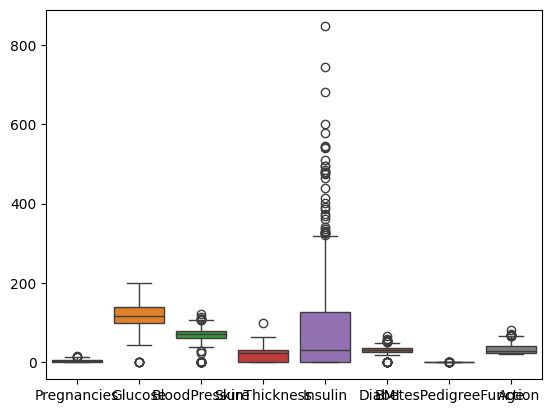

In [96]:
sns.boxplot(x)

In [97]:
mainpipeline=Pipeline(
    steps=[
        ('scaling',RobustScaler()),
        ('model',KNeighborsClassifier(n_neighbors=5,metric='euclidean'))
    ]
)
# mainpipeline.fit(xtrain,ytrain)

In [98]:
# ypred=mainpipeline.predict(xtrain)

In [99]:
# print(classification_report(ytrain,ypred))

In [100]:
gridsearch=GridSearchCV(
    estimator=mainpipeline,
    param_grid={'model__n_neighbors':[5,21,22,23,24],
                'model__metric':['euclidean','manhattan']},
    cv=10,
    n_jobs=1,
    verbose=1
    
)
gridsearch.fit(xtrain,ytrain)

Fitting 10 folds for each of 10 candidates, totalling 100 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...euclidean'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__metric': ['euclidean', 'manhattan'], 'model__n_neighbors': [5, 21, ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits

In [101]:
# model=KNeighborsRegressor(n_neighbors=5,metric='equilidean')

In [102]:
np.sqrt(xtrain.shape[0])#5,21,22,23,24 (thumb rule)

np.float64(24.779023386727733)

In [103]:
pred_ytrain=gridsearch.predict(xtrain)
pred_ytest=gridsearch.predict(xtest)

In [104]:
print(classification_report(ytrain,pred_ytrain))
print(classification_report(ytest,pred_ytest))

              precision    recall  f1-score   support

           0       0.79      0.92      0.85       401
           1       0.78      0.55      0.65       213

    accuracy                           0.79       614
   macro avg       0.79      0.73      0.75       614
weighted avg       0.79      0.79      0.78       614

              precision    recall  f1-score   support

           0       0.75      0.87      0.80        99
           1       0.67      0.47      0.55        55

    accuracy                           0.73       154
   macro avg       0.71      0.67      0.68       154
weighted avg       0.72      0.73      0.71       154



In [105]:
result=pd.DataFrame(gridsearch.cv_results_)
result

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__metric,param_model__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.021048,0.004730,0.013838,0.003351,euclidean,5,"{'model__metric': 'euclidean', 'model__n_neigh...",0.661290,0.741935,0.806452,0.693548,0.786885,0.770492,0.770492,0.721311,0.770492,0.754098,0.747700,0.042089,8
1,0.017789,0.002789,0.012339,0.001685,euclidean,21,"{'model__metric': 'euclidean', 'model__n_neigh...",0.709677,0.758065,0.838710,0.790323,0.786885,0.737705,0.770492,0.770492,0.786885,0.754098,0.770333,0.032834,2
2,0.017508,0.002620,0.012612,0.001204,euclidean,22,"{'model__metric': 'euclidean', 'model__n_neigh...",0.725806,0.741935,0.806452,0.758065,0.786885,0.754098,0.754098,0.770492,0.786885,0.770492,0.765521,0.022556,3
3,0.021173,0.006516,0.014859,0.002828,euclidean,23,"{'model__metric': 'euclidean', 'model__n_neigh...",0.741935,0.822581,0.822581,0.709677,0.786885,0.770492,0.770492,0.770492,0.786885,0.786885,0.776891,0.032151,1
4,0.014026,0.000629,0.011002,0.000992,euclidean,24,"{'model__metric': 'euclidean', 'model__n_neigh...",0.741935,0.774194,0.806452,0.725806,0.770492,0.737705,0.754098,0.704918,0.786885,0.803279,0.760576,0.031817,5
5,0.016114,0.001756,0.010604,0.000828,manhattan,5,"{'model__metric': 'manhattan', 'model__n_neigh...",0.661290,0.741935,0.790323,0.677419,0.737705,0.704918,0.737705,0.721311,0.803279,0.770492,0.734638,0.043456,10
6,0.015114,0.001220,0.012121,0.000881,manhattan,21,"{'model__metric': 'manhattan', 'model__n_neigh...",0.693548,0.725806,0.790323,0.693548,0.737705,0.754098,0.754098,0.770492,0.786885,0.721311,0.742782,0.032942,9
7,0.019661,0.004573,0.015854,0.004295,manhattan,22,"{'model__metric': 'manhattan', 'model__n_neigh...",0.693548,0.725806,0.806452,0.741935,0.754098,0.803279,0.737705,0.770492,0.786885,0.721311,0.754151,0.035301,7
8,0.015986,0.002225,0.012385,0.002111,manhattan,23,"{'model__metric': 'manhattan', 'model__n_neigh...",0.725806,0.758065,0.822581,0.709677,0.721311,0.803279,0.754098,0.803279,0.786885,0.721311,0.760629,0.038878,4
9,0.016394,0.001767,0.012360,0.000944,manhattan,24,"{'model__metric': 'manhattan', 'model__n_neigh...",0.709677,0.709677,0.822581,0.725806,0.754098,0.803279,0.754098,0.770492,0.786885,0.737705,0.757430,0.036547,6


In [106]:
model1=gridsearch.best_estimator_
model1.fit(xtrain,ytrain)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaling', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Pregnancies','Glucose','BloodPressure',...,'BMI', 'DiabetesPedigreeFunction','Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"


In [107]:
pred1_ytrain=model1.predict(xtrain)
pred1_ytest=model1.predict(xtest)

In [108]:
print(classification_report(ytrain,pred1_ytrain))
print(classification_report(ytest,pred1_ytest))

              precision    recall  f1-score   support

           0       0.79      0.92      0.85       401
           1       0.78      0.55      0.65       213

    accuracy                           0.79       614
   macro avg       0.79      0.73      0.75       614
weighted avg       0.79      0.79      0.78       614

              precision    recall  f1-score   support

           0       0.75      0.87      0.80        99
           1       0.67      0.47      0.55        55

    accuracy                           0.73       154
   macro avg       0.71      0.67      0.68       154
weighted avg       0.72      0.73      0.71       154

